# CNN 이진분류 (컬러이미지)
- 개와고양이 데이터셋

# Basic setting

### Measuring execution time

In [53]:
!pip install --q ipython-autotime
%load_ext autotime

The autotime extension is already loaded. To reload it, use:
  %reload_ext autotime
time: 2.31 s (started: 2025-01-23 04:25:07 +00:00)


### Library

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import keras
from keras import layers

import requests
import zipfile
import io
import PIL
import os


time: 715 µs (started: 2025-01-23 04:25:09 +00:00)


# Data collection

### Get zip data from Url

In [55]:
# Data URL
data_url = 'https://raw.githubusercontent.com/20161609/data_box/main/cats_and_dogs.zip'
response = requests.get(data_url)
if response.status_code == 200:
    zip_data = io.BytesIO(response.content)  # Processing in memory
    with zipfile.ZipFile(zip_data, 'r') as zip_ref:
        zip_ref.extractall('/content')  # Decompress in memory

    data_root = '/content/cats_and_dogs'
    train_dir = data_root + '/train'
    test_dir = data_root + '/test'

    # Load the training data
    train_cats_fnames = os.listdir(train_dir + '/cats')
    train_dogs_fnames = os.listdir(train_dir + '/dogs')
else:
    raise Exception(f"Failed to download data. Status code: {response.status_code}")

time: 2.41 s (started: 2025-01-23 04:25:09 +00:00)


In [56]:
class_name = ['cats', 'dogs']
X_train, y_train = [], []

for fname in train_cats_fnames:
    image = PIL.Image.open(train_dir + '/cats/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_train.append(arr)
    y_train.append(0)

for fname in train_dogs_fnames:
    image = PIL.Image.open(train_dir + '/dogs/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_train.append(arr)
    y_train.append(1)

len(X_train), len(y_train)

(2600, 2600)

time: 18.1 s (started: 2025-01-23 04:25:11 +00:00)


In [57]:
X_train = np.array(X_train)
y_train = np.array(y_train)

print(type(X_train), type(y_train))
print(X_train.shape, y_train.shape)

<class 'numpy.ndarray'> <class 'numpy.ndarray'>
(2600, 224, 224, 3) (2600,)
time: 199 ms (started: 2025-01-23 04:25:29 +00:00)


# Data Preparation

### Split: train and validation

In [58]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2,
                                                  shuffle=True,
                                                  random_state=42)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(2080, 224, 224, 3) (520, 224, 224, 3)
(2080,) (520,)
time: 260 ms (started: 2025-01-23 04:25:30 +00:00)


### Show sample images from train data

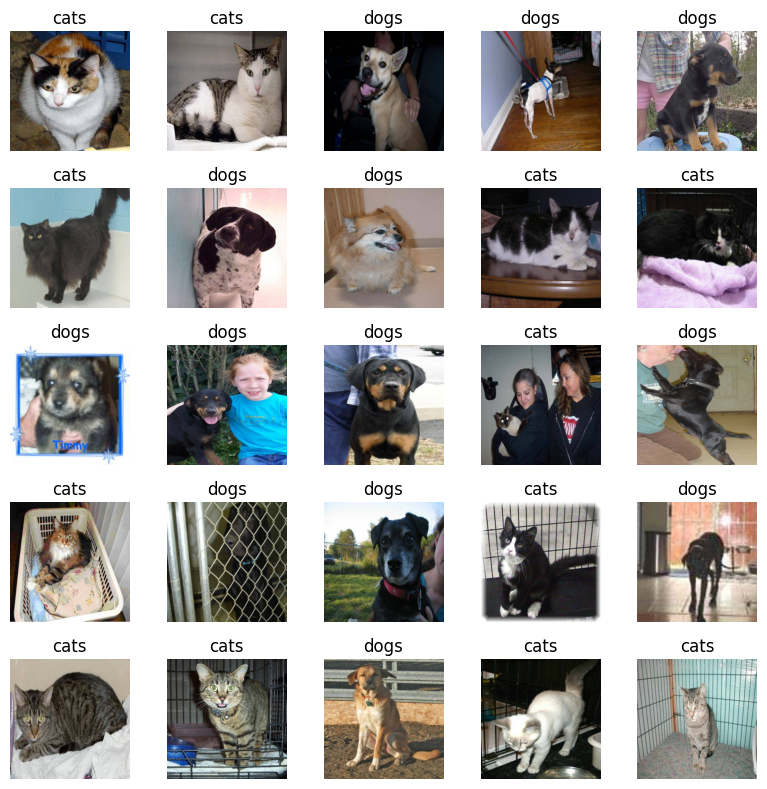

time: 4.94 s (started: 2025-01-23 04:25:30 +00:00)


In [59]:
# np.random.seed(42)
sample = np.random.randint(2080, size=25)

fig = plt.figure(figsize=(8, 8))
for i, idx in enumerate(sample):
    plt.subplot(5, 5, i+1)
    plt.imshow(X_train[idx], cmap='gray')
    plt.axis('off')
    plt.title(class_name[y_train[idx]])
fig.tight_layout()
plt.show()

# Data preprocessing

In [60]:
X_train_s = X_train.astype('float')/255.
X_val_s = X_val.astype('float')/255.

X_train_s.shape, X_val_s.shape

((2080, 224, 224, 3), (520, 224, 224, 3))

time: 4.6 s (started: 2025-01-23 04:25:35 +00:00)


# Model

### Create model

In [61]:
from keras import layers

model = keras.Sequential([
    layers.Conv2D(filters=16, kernel_size=3, activation='relu',
                  input_shape=(224, 224, 3)),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Conv2D(filters=32, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

time: 38.6 ms (started: 2025-01-23 04:25:40 +00:00)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model = keras.Sequential()
model.add(layers.Conv2D(filters=16, kernel_size=3, activation='relu',
                  input_shape=(224, 224, 3)))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(layers.MaxPooling2D())
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)                   │ (None, 222, 222, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 111, 111, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 109, 109, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 54, 54, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 52, 52, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 43264)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 256)                 │      11,075,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 16)                  │           4,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,103,553 (42.36 MB)

 Trainable params: 11,103,553 (42.36 MB)

 Non-trainable params: 0 (0.00 B)

time: 100 ms (started: 2025-01-23 04:25:40 +00:00)


### Compile model

In [63]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

time: 6.47 ms (started: 2025-01-23 04:25:40 +00:00)


### Call back

In [64]:
from keras import callbacks

es = callbacks.EarlyStopping(monitor="val_loss",patience=5)
ckpt_path = './temp/cats_dogs.weights.h5'
ckpt = keras.callbacks.ModelCheckpoint(
    ckpt_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True
)

time: 458 µs (started: 2025-01-23 04:25:40 +00:00)


### History

In [65]:
EPOCHS = 20
BATCH_SIZE = 32

history = model.fit(X_train_s, y_train,
                    epochs=EPOCHS,
                    batch_size=BATCH_SIZE,
                    callbacks=[es, ckpt],
                    validation_data=(X_val_s, y_val))

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 8s 64ms/step - accuracy: 0.5125 - loss: 0.7394 - val_accuracy: 0.5635 - val_loss: 0.6754
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 7s 50ms/step - accuracy: 0.6112 - loss: 0.6523 - val_accuracy: 0.7000 - val_loss: 0.6196
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.6881 - loss: 0.5908 - val_accuracy: 0.7135 - val_loss: 0.5768
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7907 - loss: 0.4579 - val_accuracy: 0.6981 - val_loss: 0.6213
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8199 - loss: 0.3669 - val_accuracy: 0.7058 - val_loss: 0.6254
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8829 - loss: 0.2602 - val_accuracy: 0.7288 - val_loss: 0.6741
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.9324 - loss: 0.1786 - val_accuracy: 0.7365 - val_loss: 0.7623
Epoch 8/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9604 - loss: 0.1122 - val_accuracy: 0.6962 - v

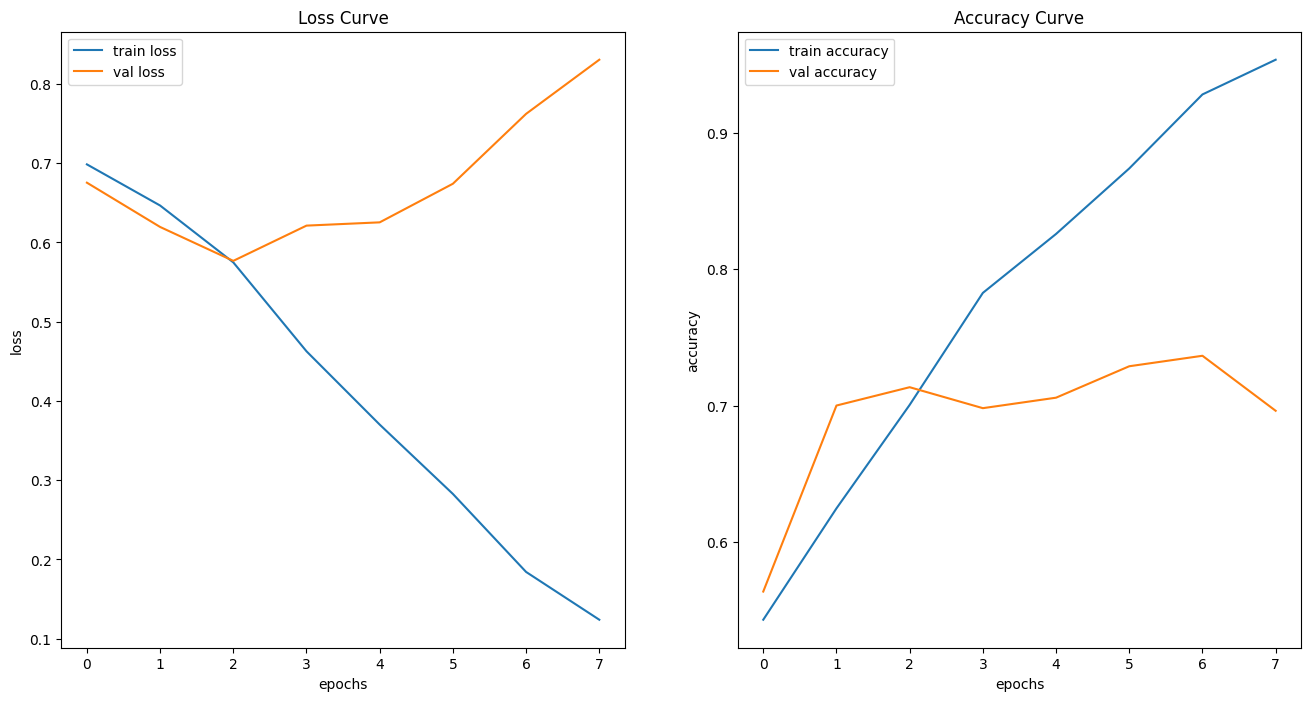

time: 296 ms (started: 2025-01-23 04:26:14 +00:00)


In [66]:
def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1, 2, 1)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.plot(hist['epoch'], hist['loss'], label='train loss')
    plt.plot(hist['epoch'], hist['val_loss'], label='val loss')
    plt.title('Loss Curve')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.plot(hist['epoch'], hist['accuracy'], label='train accuracy')
    plt.plot(hist['epoch'], hist['val_accuracy'], label='val accuracy')
    plt.title('Accuracy Curve')
    plt.legend()
    plt.show()

plot_history(history)

### Load best check point

In [67]:
model.load_weights(ckpt_path)

time: 231 ms (started: 2025-01-23 04:26:14 +00:00)


# Estimate

In [68]:
# Data preprocessing
test_cats_fnames = os.listdir(test_dir + '/cats')
test_dogs_fnames = os.listdir(test_dir + '/dogs')

X_test = []
y_test = []

for fname in test_cats_fnames:
    image = PIL.Image.open(test_dir + '/cats/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_test.append(arr)
    y_test.append(0)

for fname in test_dogs_fnames:
    image = PIL.Image.open(test_dir + '/dogs/' + fname)
    image = image.resize((224, 224))
    arr = np.array(image)
    X_test.append(arr)
    y_test.append(1)

X_test = np.array(X_test)
y_test = np.array(y_test)

# Normalization of test data
X_test_s = X_test.astype('float') / 255.

X_test.shape, y_test.shape

((400, 224, 224, 3), (400,))

time: 1.78 s (started: 2025-01-23 04:26:14 +00:00)


### Get prediction

In [69]:
y_pred_proba = model.predict(X_test_s)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

y_pred.shape

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step


(400,)

time: 1.95 s (started: 2025-01-23 04:26:16 +00:00)


### Show perfomance from test data

accuracy: 0.715
recall: 0.715
precision: 0.7151936743068762
f1 : 0.714935860568628


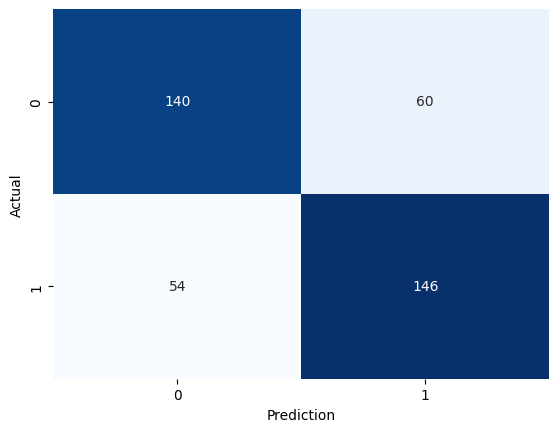

time: 95.8 ms (started: 2025-01-23 04:26:18 +00:00)


In [70]:
from sklearn.metrics import accuracy_score, recall_score, precision_score,f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred, aver='binary'):
    print('accuracy:', accuracy_score(y_true, y_pred))
    print('recall:', recall_score(y_true, y_pred ,average=aver))
    print('precision:', precision_score(y_true, y_pred,average=aver))
    print('f1 :', f1_score(y_true, y_pred, average=aver))

    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

print_metrics(y_test, y_pred, aver='macro')